# Exploratory Data Analysis — Onion Prices
**Project:** Agri Price Forecast | **Author:** Your Name

This notebook explores:
1. Price distribution and basic statistics
2. Temporal trends (2023–2025)
3. Seasonality patterns
4. Market-wise and state-wise analysis
5. Weather correlations
6. Feature correlation matrix

In [1]:
import sys
sys.path.append('..')  # So we can import src.*

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

from src.data.database import init_db, get_raw_prices_df
from src.features.engineer import build_onion_features

init_db()
print('Setup complete')

2026-05-16 19:01:04 | INFO     | src.data.database | Database schema initialised at sqlite:///C:\Users\Jeya Devi\OneDrive\Desktop\dev-projects\agri-price-forecast\data\agri_prices.db
Setup complete


## 1. Load Data

In [2]:
# Raw price data (all markets)
raw_df = get_raw_prices_df(commodity='onion')
raw_df['date'] = pd.to_datetime(raw_df['date'])
print(f'Raw records: {len(raw_df):,}')
print(f'Date range: {raw_df["date"].min().date()} to {raw_df["date"].max().date()}')
print(f'Markets: {raw_df["market"].nunique()}')
print(f'States: {raw_df["state"].nunique()}')
raw_df.head()

Raw records: 293,418
Date range: 2023-01-07 to 2025-12-05
Markets: 1044
States: 28


,date,commodity,market,state,modal_price,min_price,max_price,variety
0,2023-01-07,onion,Laxmi Sopan Agriculture Produce Marketing Co Ltd,Maharashtra,500.0,100.0,800.0,Other
1,2023-01-07,onion,Kolhapur,Maharashtra,1000.0,500.0,1800.0,Other
2,2023-01-07,onion,Farukh Nagar,Haryana,1200.0,1200.0,1500.0,Other
3,2023-01-07,onion,Batote,Jammu & Kashmir,2100.0,2000.0,2200.0,Other
4,2023-01-07,onion,Durgapur,West Bengal,1550.0,1450.0,1650.0,Other


In [3]:
# Feature matrix (daily aggregated)
feat_df = pd.read_csv('../data/processed/features_onion.csv', parse_dates=['date'])
print(f'Feature matrix: {feat_df.shape}')
feat_df[['date','modal_price','lag_7d','rolling_mean_30d','month','temp_max','precip']].describe()

Feature matrix: (641, 66)


,date,modal_price,lag_7d,rolling_mean_30d,month,temp_max,precip
count,641,641.000000,641.000000,641.000000,641.000000,641.000000,641.000000
mean,2024-05-21 03:49:08.517940736,2646.907677,2681.484172,2699.647130,6.605304,31.962832,3.189938
min,2023-02-07 00:00:00,1197.441176,1197.441176,1490.994386,1.000000,25.875000,0.000000
25%,2023-11-14 00:00:00,1780.636929,1766.080087,2184.973705,4.000000,28.800000,0.000000
50%,2024-05-01 00:00:00,2171.009217,2148.135977,2338.048631,7.000000,30.600000,0.525000
75%,2024-11-04 00:00:00,3506.861224,3744.976987,3475.589946,9.000000,35.175000,4.425000
max,2025-12-05 00:00:00,5303.508591,5303.508591,4532.192545,12.000000,41.075000,31.275000
std,NaN,1076.391485,1125.190348,776.288403,3.299892,3.919086,5.216913


## 2. Price Distribution

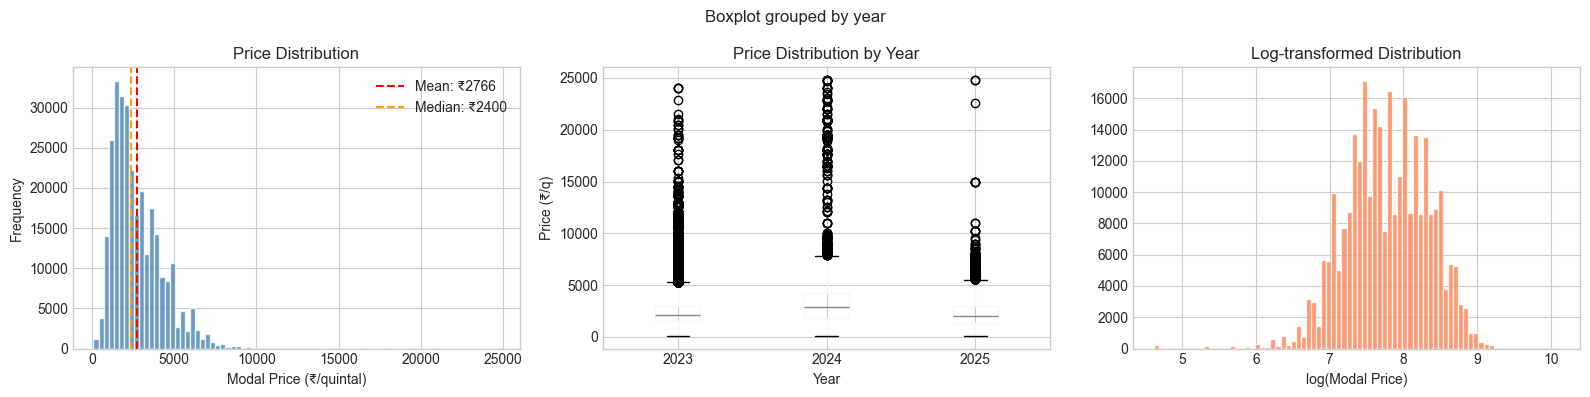

Mean:   ₹2766/q
Median: ₹2400/q
Std:    ₹1586/q
Min:    ₹100/q
Max:    ₹24780/q
CV:     57.4% (high = volatile)


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histogram
axes[0].hist(raw_df['modal_price'], bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Modal Price (₹/quintal)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Price Distribution')
axes[0].axvline(raw_df['modal_price'].mean(), color='red', linestyle='--', label=f'Mean: ₹{raw_df["modal_price"].mean():.0f}')
axes[0].axvline(raw_df['modal_price'].median(), color='orange', linestyle='--', label=f'Median: ₹{raw_df["modal_price"].median():.0f}')
axes[0].legend()

# Box plot by year
raw_df['year'] = raw_df['date'].dt.year
raw_df.boxplot(column='modal_price', by='year', ax=axes[1])
axes[1].set_title('Price by Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Price (₹/q)')
plt.sca(axes[1])
plt.title('Price Distribution by Year')

# Log distribution
axes[2].hist(np.log1p(raw_df['modal_price']), bins=80, color='coral', edgecolor='white', alpha=0.8)
axes[2].set_xlabel('log(Modal Price)')
axes[2].set_title('Log-transformed Distribution')

plt.tight_layout()
plt.savefig('../docs/eda_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean:   ₹{raw_df['modal_price'].mean():.0f}/q")
print(f"Median: ₹{raw_df['modal_price'].median():.0f}/q")
print(f"Std:    ₹{raw_df['modal_price'].std():.0f}/q")
print(f"Min:    ₹{raw_df['modal_price'].min():.0f}/q")
print(f"Max:    ₹{raw_df['modal_price'].max():.0f}/q")
print(f"CV:     {raw_df['modal_price'].std()/raw_df['modal_price'].mean()*100:.1f}% (high = volatile)")

## 3. Temporal Trend

In [5]:
# Daily national average
daily = raw_df.groupby('date')['modal_price'].agg(['mean','min','max']).reset_index()
daily.columns = ['date','mean_price','min_price','max_price']

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=daily['date'], y=daily['mean_price'],
    mode='lines', name='Daily Avg Price',
    line=dict(color='#2563EB', width=1.5)
))
fig.add_trace(go.Scatter(
    x=pd.concat([daily['date'], daily['date'][::-1]]),
    y=pd.concat([daily['max_price'], daily['min_price'][::-1]]),
    fill='toself', fillcolor='rgba(37,99,235,0.1)',
    line=dict(color='rgba(255,255,255,0)'), name='Min-Max Range'
))

# Add 30-day rolling average
daily['rolling_30d'] = daily['mean_price'].rolling(30).mean()
fig.add_trace(go.Scatter(
    x=daily['date'], y=daily['rolling_30d'],
    mode='lines', name='30-day Rolling Avg',
    line=dict(color='#DC2626', width=2)
))

fig.update_layout(
    title='Onion Price Trend 2023–2025 (All India Average)',
    xaxis_title='Date', yaxis_title='Price (₹/quintal)',
    hovermode='x unified', template='plotly_white', height=450
)
fig.show()
fig.write_html('../docs/eda_price_trend.html')
print('Saved interactive chart to docs/eda_price_trend.html')

Saved interactive chart to docs/eda_price_trend.html


## 4. Seasonality Analysis

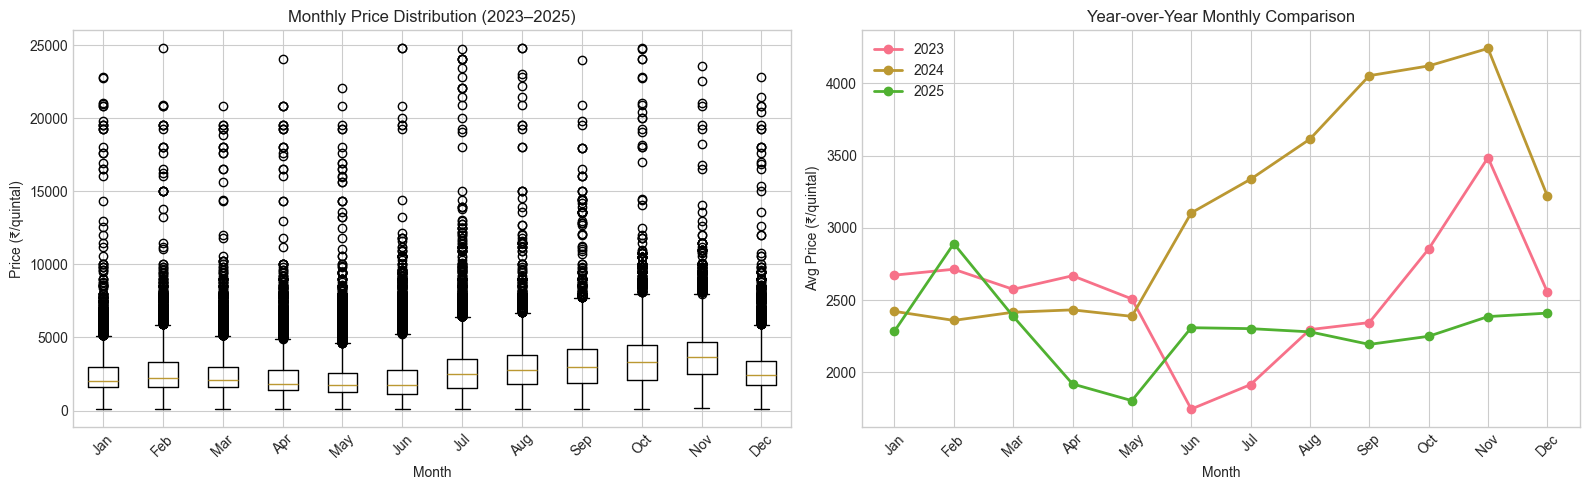

Key insight: Onion prices typically peak in Oct-Nov (post-Kharif supply gap) and dip in Feb-Apr (Rabi harvest)


In [6]:
raw_df['month'] = raw_df['date'].dt.month
raw_df['month_name'] = raw_df['date'].dt.strftime('%b')
raw_df['year'] = raw_df['date'].dt.year

month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_avg = raw_df.groupby(['year','month','month_name'])['modal_price'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Monthly box plot (all years combined)
monthly_all = raw_df.groupby('month_name')['modal_price'].apply(list)
axes[0].boxplot([monthly_all.get(m, [0]) for m in month_order], labels=month_order)
axes[0].set_title('Monthly Price Distribution (2023–2025)')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Price (₹/quintal)')
axes[0].tick_params(axis='x', rotation=45)

# Year-over-year comparison
for year in sorted(raw_df['year'].unique()):
    yr_data = raw_df[raw_df['year']==year].groupby('month')['modal_price'].mean()
    axes[1].plot(yr_data.index, yr_data.values, marker='o', label=str(year), linewidth=2)
axes[1].set_title('Year-over-Year Monthly Comparison')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Avg Price (₹/quintal)')
axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels(month_order)
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../docs/eda_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()
print('Key insight: Onion prices typically peak in Oct-Nov (post-Kharif supply gap) and dip in Feb-Apr (Rabi harvest)')

## 5. Top Markets Analysis

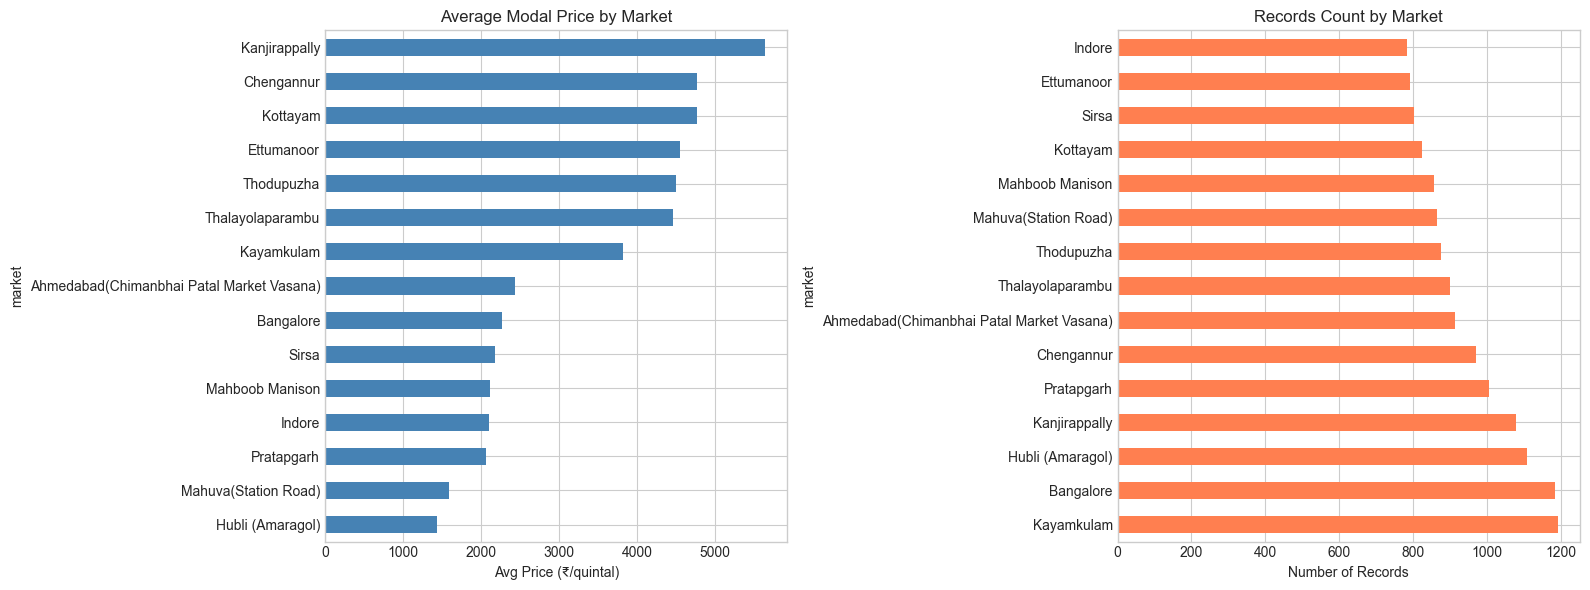


Top 5 markets by avg price:
market
Kanjirappally    5649.721707
Chengannur       4774.074074
Kottayam         4766.140777
Ettumanoor       4556.439394
Thodupuzha       4502.168950
Name: mean, dtype: float64


In [7]:
# Top 15 markets by record count
top_markets = raw_df['market'].value_counts().head(15)
market_stats = raw_df[raw_df['market'].isin(top_markets.index)].groupby('market')['modal_price'].agg(['mean','std','min','max'])
market_stats = market_stats.sort_values('mean', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

market_stats['mean'].plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Average Modal Price by Market')
axes[0].set_xlabel('Avg Price (₹/quintal)')

top_markets.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Records Count by Market')
axes[1].set_xlabel('Number of Records')

plt.tight_layout()
plt.savefig('../docs/eda_markets.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 5 markets by avg price:')
print(market_stats['mean'].sort_values(ascending=False).head())

## 6. State-wise Analysis

In [8]:
state_avg = raw_df.groupby('state')['modal_price'].agg(['mean','count']).reset_index()
state_avg = state_avg[state_avg['count'] > 100].sort_values('mean', ascending=False)

fig = px.bar(
    state_avg.head(20), x='state', y='mean',
    title='Average Onion Price by State (min 100 records)',
    labels={'mean': 'Avg Price (₹/q)', 'state': 'State'},
    color='mean', color_continuous_scale='Blues'
)
fig.update_layout(xaxis_tickangle=45, template='plotly_white')
fig.show()

## 7. STL Decomposition

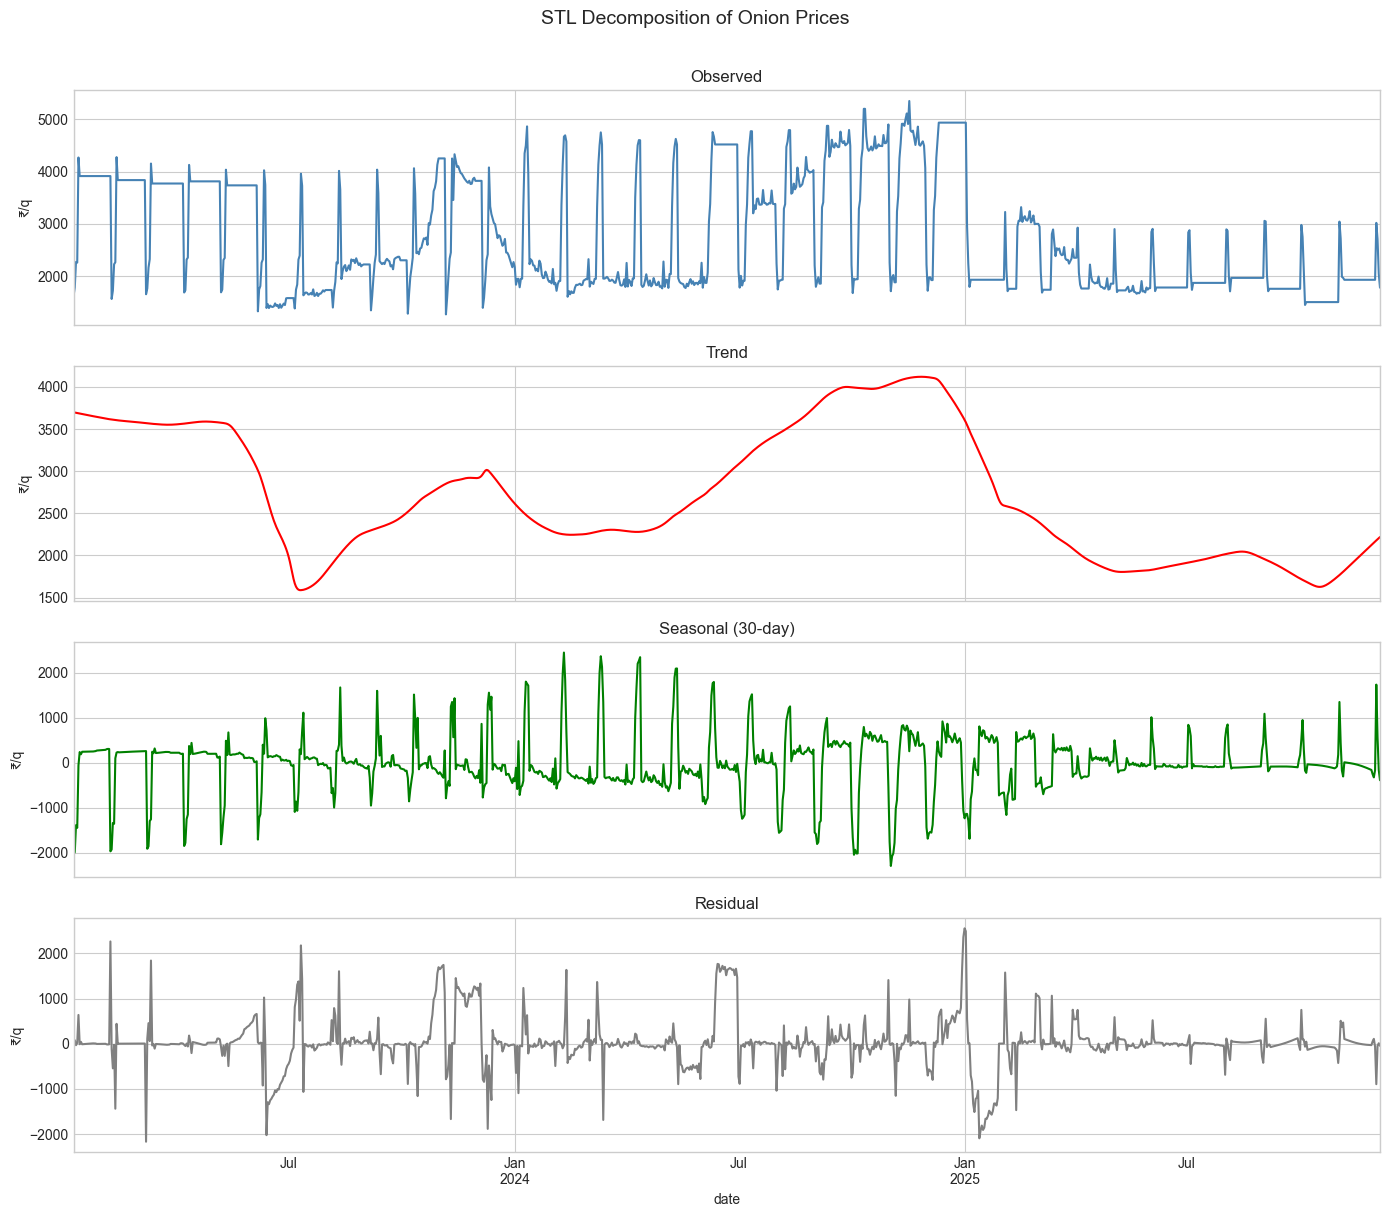

Trend strength:    0.668 (>0.6 = strong trend)
Seasonal strength: 0.509 (>0.6 = strong seasonality)


In [9]:
from statsmodels.tsa.seasonal import STL

# Use daily aggregated series
daily_series = daily.set_index('date')['mean_price'].dropna()
daily_series = daily_series.asfreq('D').ffill()

stl = STL(daily_series, period=30, robust=True)
result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
result.observed.plot(ax=axes[0], title='Observed', color='steelblue')
result.trend.plot(ax=axes[1], title='Trend', color='red')
result.seasonal.plot(ax=axes[2], title='Seasonal (30-day)', color='green')
result.resid.plot(ax=axes[3], title='Residual', color='gray')

for ax in axes:
    ax.set_ylabel('₹/q')

plt.suptitle('STL Decomposition of Onion Prices', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../docs/eda_stl_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

trend_strength = 1 - result.resid.var() / (result.trend + result.resid).var()
season_strength = 1 - result.resid.var() / (result.seasonal + result.resid).var()
print(f'Trend strength:    {trend_strength:.3f} (>0.6 = strong trend)')
print(f'Seasonal strength: {season_strength:.3f} (>0.6 = strong seasonality)')

## 8. Weather Correlation

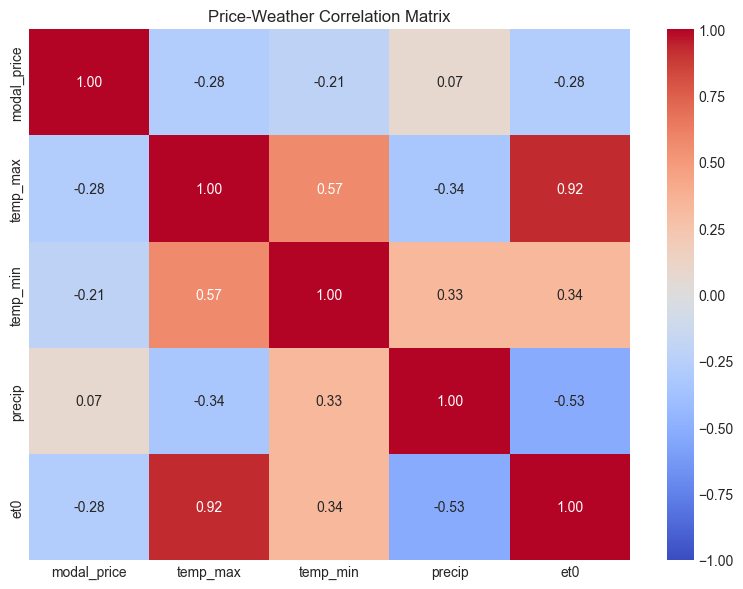


Correlations with modal_price:
precip      0.071947
temp_min   -0.213839
et0        -0.284267
temp_max   -0.284960
Name: modal_price, dtype: float64


In [10]:
weather_cols = [c for c in feat_df.columns if c in ['temp_max','temp_min','precip','et0']]
if weather_cols:
    corr_cols = ['modal_price'] + weather_cols
    corr = feat_df[corr_cols].corr()
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
    plt.title('Price-Weather Correlation Matrix')
    plt.tight_layout()
    plt.savefig('../docs/eda_weather_correlation.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('\nCorrelations with modal_price:')
    print(corr['modal_price'].drop('modal_price').sort_values(ascending=False))
else:
    print('No weather columns found — run scraper_weather.py first')

## 9. Feature Correlation Matrix

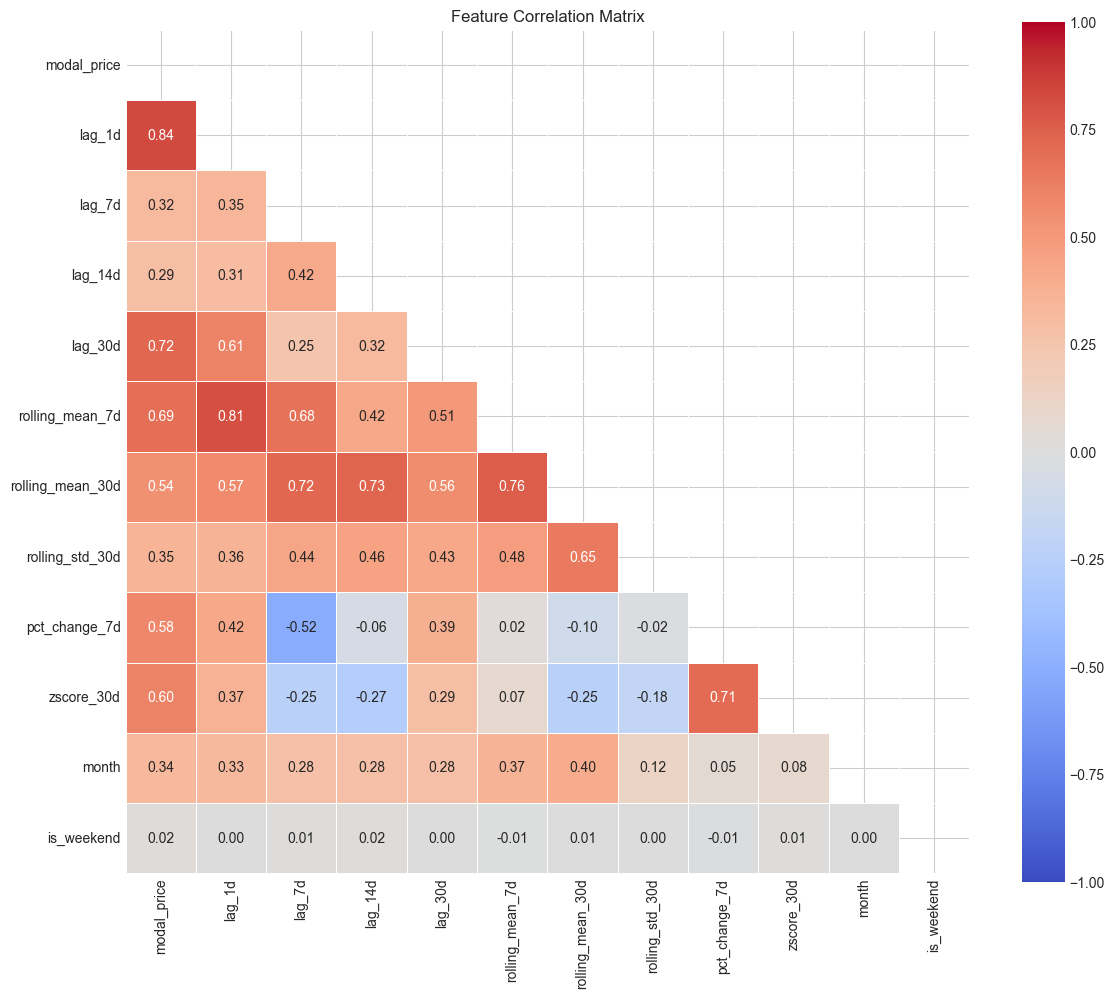


Top features correlated with modal_price:
lag_1d              0.835670
lag_30d             0.724035
rolling_mean_7d     0.688929
zscore_30d          0.604122
pct_change_7d       0.580958
rolling_mean_30d    0.540453
rolling_std_30d     0.354139
month               0.335729
lag_7d              0.315874
lag_14d             0.292191
Name: modal_price, dtype: float64


In [11]:
key_features = [
    'modal_price','lag_1d','lag_7d','lag_14d','lag_30d',
    'rolling_mean_7d','rolling_mean_30d','rolling_std_30d',
    'pct_change_7d','zscore_30d','month','is_weekend'
]
available = [c for c in key_features if c in feat_df.columns]
corr = feat_df[available].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('../docs/eda_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nTop features correlated with modal_price:')
print(corr['modal_price'].drop('modal_price').abs().sort_values(ascending=False).head(10))

## 10. Summary Statistics for Paper

In [12]:
print('='*60)
print('DATASET SUMMARY — for IEEE paper Table 1')
print('='*60)
print(f'Total observations:      {len(raw_df):,}')
print(f'Date range:              {raw_df["date"].min().date()} to {raw_df["date"].max().date()}')
print(f'Unique markets:          {raw_df["market"].nunique()}')
print(f'Unique states:           {raw_df["state"].nunique()}')
print(f'Mean price:              ₹{raw_df["modal_price"].mean():.0f}/quintal')
print(f'Std deviation:           ₹{raw_df["modal_price"].std():.0f}/quintal')
print(f'Coefficient of variation:{raw_df["modal_price"].std()/raw_df["modal_price"].mean()*100:.1f}%')
print(f'Min price:               ₹{raw_df["modal_price"].min():.0f}/quintal')
print(f'Max price:               ₹{raw_df["modal_price"].max():.0f}/quintal')
print(f'Feature matrix shape:    {feat_df.shape}')
print(f'Weather features:        {len([c for c in feat_df.columns if c in ["temp_max","temp_min","precip","et0"]])}')
print('='*60)

DATASET SUMMARY — for IEEE paper Table 1
Total observations:      293,418
Date range:              2023-01-07 to 2025-12-05
Unique markets:          1044
Unique states:           28
Mean price:              ₹2766/quintal
Std deviation:           ₹1586/quintal
Coefficient of variation:57.4%
Min price:               ₹100/quintal
Max price:               ₹24780/quintal
Feature matrix shape:    (641, 66)
Weather features:        4
